In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Sequence

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import efficient_su2
from dyn_esu2 import dynamic_esu2
from estimator import MyEstimator

from qiskit.transpiler import PassManager
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler

from itertools import product

import hamiltonian_generator

import warnings
warnings.filterwarnings("ignore")

In [2]:
n, h = 3, 0.5
base_hamiltonian = hamiltonian_generator.get_heisenberg_hamiltonian(n, h)
dynamic_hamiltonian = hamiltonian_generator.get_dynamic_heisenberg_hamiltonian(n, h)
print(base_hamiltonian)
print(dynamic_hamiltonian)

SparsePauliOp(['XXI', 'YYI', 'ZZI', 'IXX', 'IYY', 'IZZ', 'ZII', 'IZI', 'IIZ'],
              coeffs=[1. +0.j, 1. +0.j, 1. +0.j, 1. +0.j, 1. +0.j, 1. +0.j, 0.5+0.j, 0.5+0.j,
 0.5+0.j])
SparsePauliOp(['IIXXI', 'IIYYI', 'IIZZI', 'IIIXX', 'IIIYY', 'IIIZZ', 'IIZII', 'IIIZI', 'IIIIZ'],
              coeffs=[1. +0.j, 1. +0.j, 1. +0.j, 1. +0.j, 1. +0.j, 1. +0.j, 0.5+0.j, 0.5+0.j,
 0.5+0.j])


In [3]:
# static_ansatz  = efficient_su2(n, reps=2)
# static_ansatz.add_register(ClassicalRegister(n, 'meas'))
dynamic_ansatz = dynamic_esu2(n, 2, mcm=True, stretch_dd=False, folds=1)

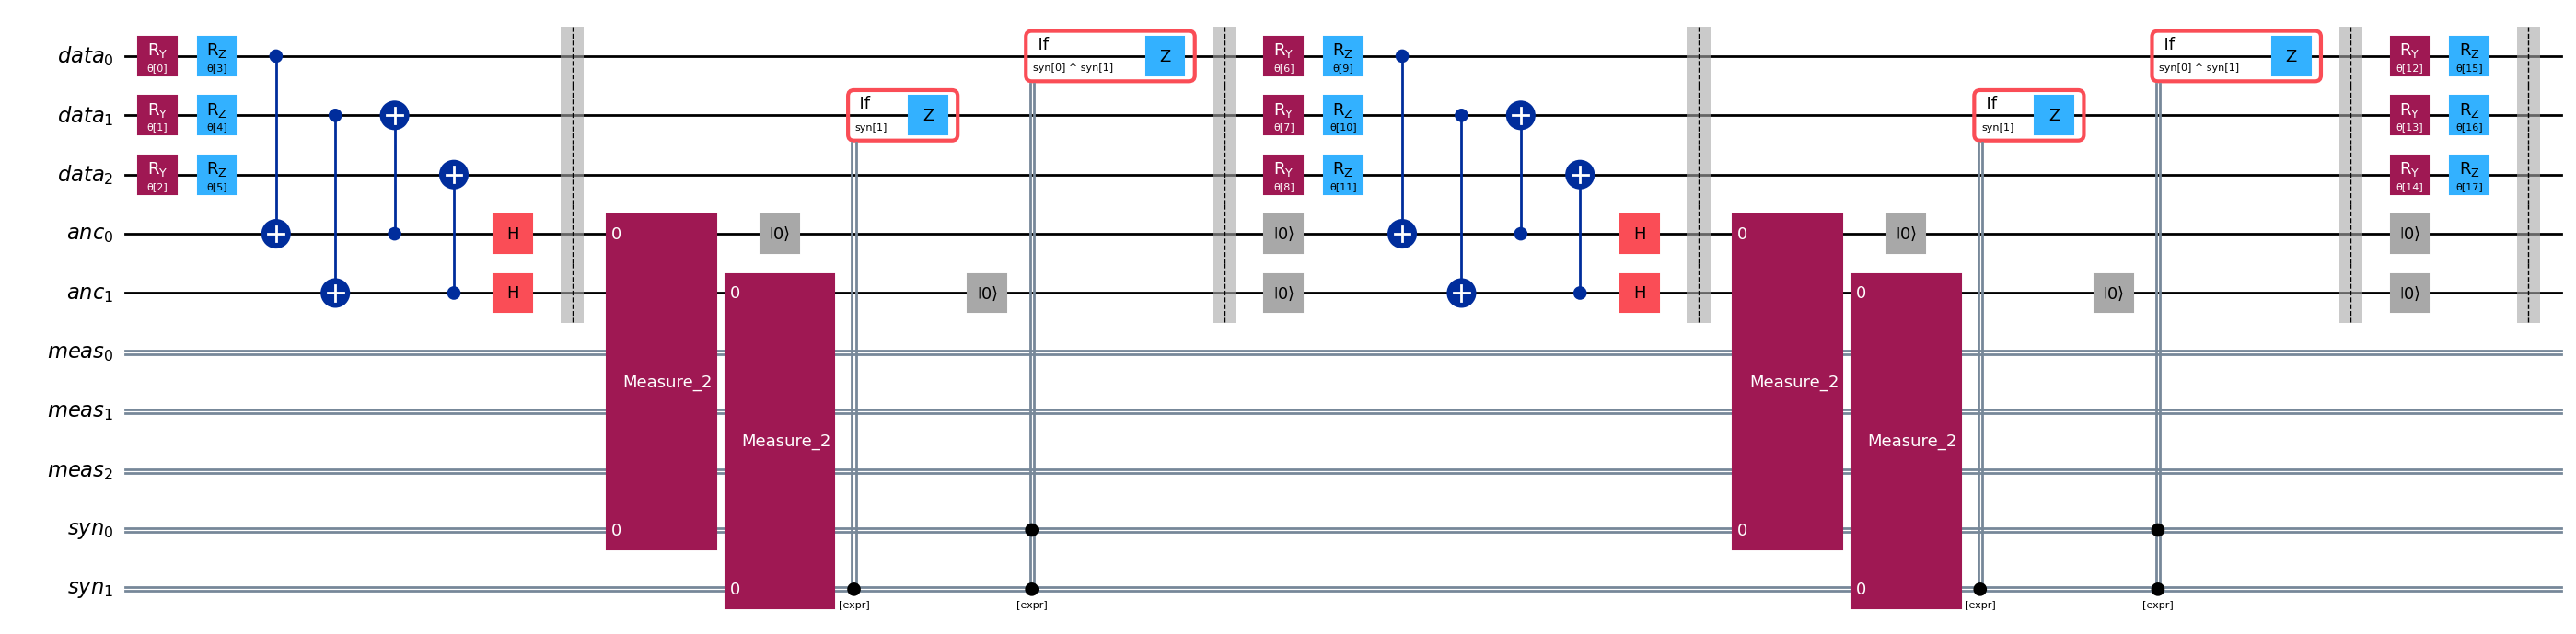

In [4]:
dynamic_ansatz.draw("mpl", style="iqp", fold=False)

In [5]:
opt_params = np.load(f'params/params_{n}_{h}.npy')
print(opt_params)

[ 2.18073532  7.18159658  3.95052835  4.08669065  0.99503858  0.67067002
 -0.61076753  6.22470802  4.15673185  4.20868743  1.63310684  6.57482348
  5.84002051  0.79209019  1.05092746  0.70812065  1.49760969  4.0099266 ]


In [6]:
service = QiskitRuntimeService()
backend_name = 'ibm_kingston'
backend = service.backend(backend_name)

qiskit_runtime_service.__init__:WARNING:2026-04-28 06:05:38,259: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (premium), the available account instances are: m5000-eu, m5000-us. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-28 06:05:38,260: Using instance: m5000-us, plan: premium


In [7]:
sampler = Sampler(backend)

In [8]:
dynamic_estimator = MyEstimator(
    'test_dynamic_estimator', dynamic_ansatz, opt_params, dynamic_hamiltonian, sampler, service, backend)

dynamic_estimator.submit_sampler_jobs()
print(dynamic_estimator.evaluate_expectation_value())

Sampler jobs already submitted. Result in jobs/test_dynamic_estimator.json.
-2.34326171875


In [9]:
folded_dd_dynamic_ansatz = dynamic_esu2(n, 2, mcm=True, stretch_dd=True, folds=5)

In [10]:
folded_dynamic_estimator = MyEstimator(
    'test_folded_dynamic_estimator', folded_dd_dynamic_ansatz, opt_params, dynamic_hamiltonian, sampler, service, backend)

folded_dynamic_estimator.submit_sampler_jobs()
print(folded_dynamic_estimator.evaluate_expectation_value())

-0.505126953125
